## 1 c)

In [98]:
# Importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt
import time

In [99]:
# Lager funksjonen beskrevet i oppgaven

def RungeKutta_32(x_init, x_end, y_init, f, alpha, h_0, tol):
    n = 0                           # Teller antall steg som aksepteres
    n_total = 0                     # Teller antall steg som testes
    h_n = h_0                       # Steglengde ved steg n
    x_n = x_init                    # x-verdi ved steg n
    y_n = y_init                    # y-vektor ved steg n
    
    x_array = [x_n]                 # Liste med x-verdier for hvert steg
    y_matrix = [y_n]                # 2D-liste med y-vektor for hvert steg 
    step_array = []                 # Liste til steglengde for hvert steg


    k_1 = f(x_init, y_init)

    while (x_end - x_n) > 0:
        h_n = min(h_n, x_end - x_n)
        k_2 = f(x_n + (1/2)*h_n, y_n + (1/2)*h_n*k_1)
        k_3 = f(x_n + (3/4)*h_n, y_n + (3/4)*h_n*k_2)

        y_next = y_n + (1/9)*h_n*(2*k_1 + 3*k_2 + 4*k_3)                # Midlertidig oppdatering av y
        x_next = x_n + h_n                                              # Midlertidig oppdatering av x

        k_4 = f(x_next, y_next)
        z_next = y_n + (1/24)*h_n*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)       # Beregner alternativ y for sammenligning

        est = abs(y_next[0] - z_next[0])
        if est < tol:                                                   # Sjekker om skrittet aksepteres
            n += 1                                                      # Oppdaterer antall skritt
            k_1 = k_4                                                   # Oppdaterer k_1
            
            x_array.append(x_next)                                      # Legger til x-verdi i listen siden skrittet aksepteres
            y_matrix.append(y_next)                                     # Legger til y-vektor i listen siden skrittet aksepteres
            step_array.append(h_n)                                      # Legger til steglengde i listen siden skrittet aksepteres
            
            x_n = x_next                                                # Oppdaterer x-verdi siden skrittet aksepteres
            y_n = y_next                                                # Oppdaterer y-vektor siden skrittet aksepteres

        h_new = alpha*h_n*(tol/est)**(1/3)                              # Beregner ny steglengde  
        h_n = h_new                                                     # Oppdaterer steglengden

        n_total += 1                                                    # Oppdaterer antall testede skritt


    return np.array(x_array), np.array(y_matrix), np.array(step_array), n, n_total

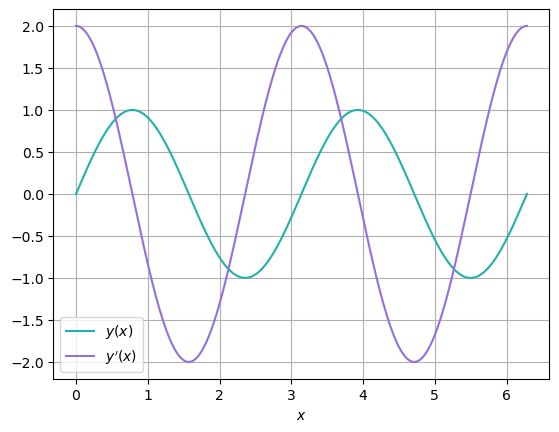

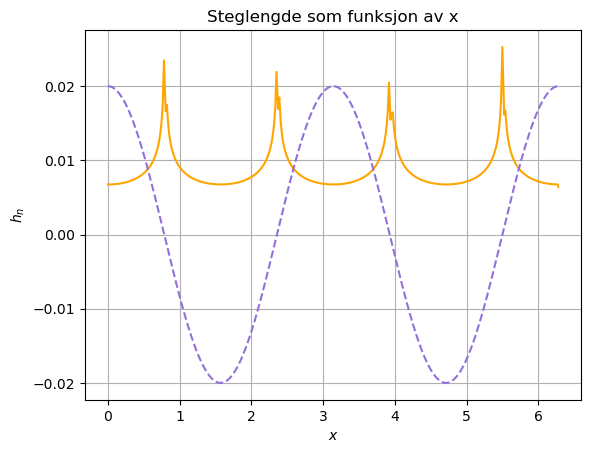

In [100]:
# Beregner y(x) og y'(x)

x_init, x_end = 0, 2*np.pi
alpha = 0.8
tol = 10**(-7)
h_0 = 0.01

y_init = np.array([0, 2])

def f_array(x, y_array):                                                   # Definerer f som returnerer vektor
    f = -4*np.sin(2*x)                                                    
    f_array = np.array([y_array[1], f])
    return f_array


x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f_array, alpha, h_0, tol) 
y_values = y_matrix[:, 0]                                                   # Henter y-verdier
dy_values = y_matrix[:, 1]                                                  # Henter dy-verdier


# Plotter y(x) og y'(x)
plt.plot(x_values, y_values, label = '$y(x)$', color = 'lightseagreen')
plt.plot(x_values, dy_values, label = "$y'(x)$", color = 'mediumpurple')
plt.xlabel('$x$')
plt.grid()
plt.legend()
plt.show()

# Plotter steglengden som funksjon av x
plt.plot(x_values[:-1], step_array, color = 'orange')
plt.plot(x_values, 0.01*dy_values, label = '$y(x)$', color = 'mediumpurple', linestyle = '--')

plt.title('Steglengde som funksjon av x')
plt.xlabel('$x$')
plt.ylabel('$h_n$')
plt.grid()
plt.show() 

Fra plottene over ser vi at steglengden har maksimumspunkter der y'(x) har vendepunkter. 
y'(x) har vendepunkter der stigningstallet til funksjonen endrer seg minst. Siden stigningstallet endrer seg relativt lite, kan man tillate seg å ha lenger steglengde rundt disse x-verdiene.

Vi ser også at steglengden har minimumspunkter der y'(x) har ekstremalpunkter. 
I ekstremalpunktene til y'(x) endrer stigningstallet seg mest, og det er naturlig at man må ta mindre steg rundt disse x-verdiene for å minimere feilen i approksimasjonen. 

## 1 d)

In [101]:
def analyticalSolution(x):                          # Funksjon for å beregne analytisk løsning
    y = np.sin(2*x)
    return y


def maxActualError(x_init, x_end, y_init, f_array, alpha, h_0, tol):
    x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f_array, alpha, h_0, tol) 
    y_values_RK = y_matrix[:, 0] 

    y_values_analytical = analyticalSolution(x_values) # Liste med analytisk løsning 

    error = abs(y_values_analytical - y_values_RK)     # Beregner absoluttfeil i alle punkter
    maxError = max(error)                              # Finner største feilen

    return maxError

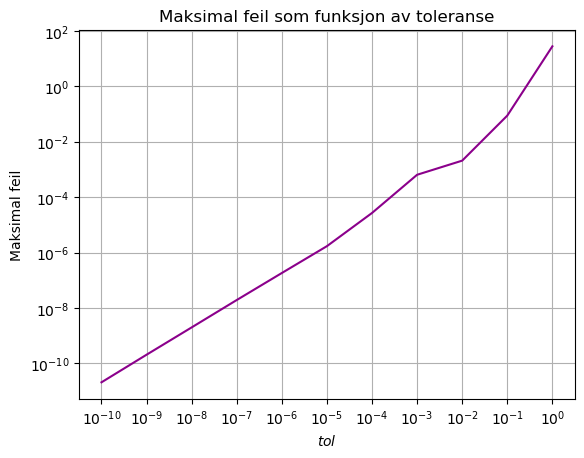

In [102]:
tol_array = np.array([10**i for i in range(-10, 1)])   # Array med ulike toleranser
maxError_array = []                                    # Liste til maksimalfeil for ulike toleranser
for tol in tol_array:       
    maxError_array.append(maxActualError(x_init, x_end, y_init, f_array, alpha, h_0, tol))  # Henter maksimal feil for hver toleranse


# Plotter maksimalfeil som funksjon av toleransen
plt.plot(tol_array, maxError_array, color = 'darkmagenta')
plt.title('Maksimal feil som funksjon av toleranse')

plt.xlabel('$tol$')
plt.xscale('log')
plt.xticks(tol_array)
plt.yscale('log')
plt.ylabel('Maksimal feil')

plt.grid()
plt.show()

Plottet over viser hvordan den maksimale feilen mellom analytisk og numerisk løsning endres som funksjon av toleransen. 
Resultatet over stemmer godt overens med intuisjonen da større toleranse for feil naturligvis vil medføre større feil i den numeriske metoden. 

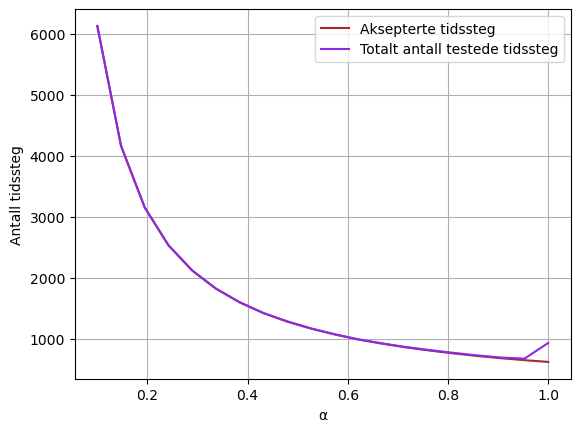

In [103]:
alpha_array = np.linspace(0.1, 1.0, 20)             # Array med ulike alfa-verdier
tolerance = 10**(-7)

n_array = []                                        # Liste for antall aksepterte tidssteg
n_total_array = []                                  # Liste for totalt antall testede tidssteg

for alphaValue in alpha_array:                      # Itererer gjennom alle alfaverdier
    x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f_array, alphaValue, h_0, tolerance)
    n_array.append(n)                               # Lagrer antall aksepterte tidssteg for gitt alfa           
    n_total_array.append(n_total)                   # Lagrer totalt antall testede tidssteg for gitt alfa


# Plotter antall tidssteg som funksjon av alfa
plt.plot(alpha_array, n_array, label = 'Aksepterte tidssteg', color = 'brown')
plt.plot(alpha_array, n_total_array, label = 'Totalt antall testede tidssteg', color = 'blueviolet')
plt.xlabel('α')
plt.ylabel('Antall tidssteg')
plt.legend()
plt.grid()
plt.show()

$α$ er en såkalt pessimistfaktor som er med på å balansere nøyaktigheten til Runge-Kutta-metoden mot effektiviteten til metoden. $α$-verdien avgjør hvor drastisk steglengden endrer seg mellom iterasjoner. 

Av plottet over ser vi at lave verdier for $α$ gir svært mange tidssteg. For lave $α$-verdier er man pessimistisk og $h_n$ holder seg svært lav, noe som resulterer i mange tidssteg. 

Plottet over viser at det å velge høyere $α$-verdier raskt vil kreve et mindre antall tidssteg i Runge-Kutta-metoden. 
Ved høye $α$-verdier er man optimistisk, og $h_n$ endrer seg drastisk for hver iterasjon. Dette resulterer i færre tidssteg, men ved for høye $α$-verdier vil det også føre til at flere tidssteg blir avvist. I plottet over ser vi at antall testede tidssteg plutselig stiger når $α$ nærmer seg 1.0. 
Dette er fordi tidsstegene blir så store at flere blir avvist og dermed må beregnes på nytt. 

## 1 e)

In [104]:
def rootFinder(g, z0, z1, tol, max_iter = 100): 
    b_values = [z0, z1]                                         # Lager liste med b-verdier

    for i in range(max_iter):                                   # Sørger for grense på antall iterasjoner

        g_z0, g_z1 = g(z0), g(z1)                               # Definerer funksjonsverdiene
        
        if abs(g_z1 - g_z0) < tol:                              # Unngår divisjon med null            
            print("For små forskjeller i funksjonsverdi")
            break 

        z2 = z1 - g_z1*(z1 - z0)/(g_z1 - g_z0)                  # Beregner ny b-verdi med sekantmetoden
        b_values.append(z2)                                     # Lagrer ny b-verdi

        if abs(z2 - z1) < tol:                                  # Sjekke konvergens
            return z2, np.array(b_values)                       # Returnerer b-verdien derom den konvergerer
 
        z0, z1 = z1, z2                                         # Oppdaterer gjettene
    raise ValueError("")

In [105]:
def g(z): 
    return z + np.sin(z) + np.cos(z)            # Definerer funksjonen g(z) = z + sin(z) + cos(z)

# Tester rootFinder
z0 = -1
z1 = 0
tol = 1e-6

root, root_array = rootFinder(g, z0, z1, tol)
print(f"Rot funnet: {root}")
print(f"Funksjonsverdien til roten: {g(root)}")        # Bekrefter at riktig rot er funnet

Rot funnet: -0.456624704567631
Funksjonsverdien til roten: -3.3306690738754696e-16


## 1 f)

In [106]:
def solveBVproblem(x_init, x_end, f, z0, z1, alpha, h_0, tol):    # Definerer funksjon for å løse randverdiproblem
    xb_values = []                                                # Liste for å lagre alle testede løsninger
    yb_values = []                                                # Liste for å lagre alle testede løsninger

    def g(b):                                                     # Definerer funksjonen for siste grensebetingelse, gitt b
        y_init = np.array([0, b])                           
        x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f, alpha, h_0, tol) # Løser IVP for gitt b
        y_end = y_matrix[-1, 0]                                   # Henter siste y-verdi    

        return y_end


    b, b_values = rootFinder(g, z0, z1, tol, max_iter=100)        # Henter b som gir oppfylt grensebetingelse og liste med testede b'er

    for value in b_values:                                        # Itererer gjennom alle testede b-verdier
        y_init = np.array([0, value])
        x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f, alpha, h_0, tol) # Løser IVP for riktig b   
        xb_values.append(x_values)                                 # Henter x-verdier for gitt b
        yb_values.append(y_matrix[:, 0])                           # Henter y-verdier for gitt b

    return xb_values, yb_values, b_values


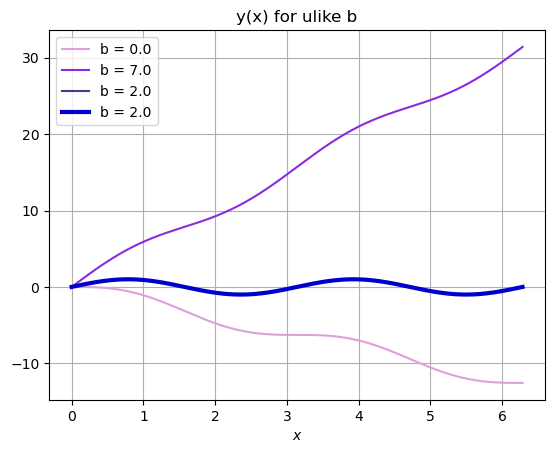

In [107]:
# Løser randverdiproblem

alpha = 0.8
h_0 = 0.01
tol = 10**(-7)

x_init, x_end = 0, 2*np.pi
z0, z1 = 0, 7                                                              # Initielle gjett z0 og z1

def f_array(x, y_array):                                                   # Definerer f som returnerer vektor
    f = -4*np.sin(2*x)                                                    
    f_array = np.array([y_array[1], f])
    return f_array


xb_values, yb_values, b_values = solveBVproblem(x_init, x_end, f_array, z0, z1, alpha, h_0, tol) # Løser randverdiproblem

iteration_num = len(yb_values)                                             # Antall testede b-verdier
colors = ["plum", "blueviolet", "darkslateblue", "royalblue"]

for i in range(iteration_num - 1):                                         # Itererer gjennom alle b-verdier unntatt den endelige                                          
    plt.plot(xb_values[i], yb_values[i], color = colors[i], label = f'b = {round(b_values[i], 3)}')


# Plotter den riktige løsningen av randverdiproblemet
plt.plot(xb_values[-1], yb_values[-1], label = f'b = {round(b_values[-1], 3)}', color = "mediumblue", linewidth = 3) 
plt.xlabel("$x$")
plt.title("y(x) for ulike b")
plt.grid()
plt.legend()
plt.show()

## 1 g)

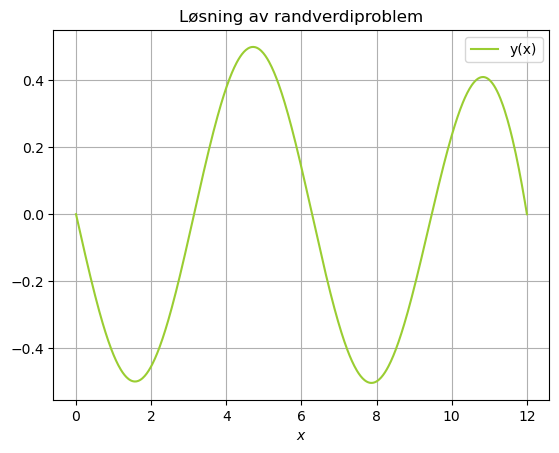

In [108]:
def g_array(x, y_array):                                            # Definerer funksjon g som returnerer vektor
    g_array = np.array([y_array[1], y_array[0] + np.sin(x)])
    return g_array


alpha = 0.8
h_0 = 0.01
tol = 10**(-7)

x_init, x_end = 0, 12
z0, z1 = 0, 1

start_shootingMethod = time.time()                                  # Variabel for startverdi for kjøretid

xb_values, yb_values, b_values = solveBVproblem(x_init, x_end, g_array, z0, z1, alpha, h_0, tol) # Finner løsning av randverdiproblemet

end_shootingMethod = time.time()                                    # Variabel for sluttverdi for kjøretid


# Plotter y(x)
plt.plot(xb_values[-1], yb_values[-1], label = "y(x)", color = "yellowgreen")
plt.title("Løsning av randverdiproblem")
plt.xlabel("$x$")
plt.grid()
plt.legend()
plt.show()

## 1h)

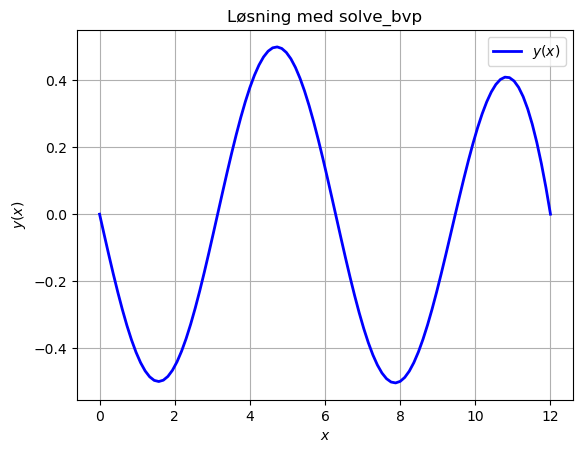

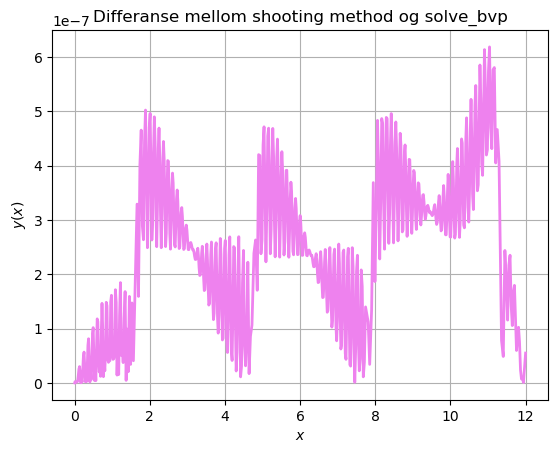

In [109]:
from scipy.integrate import solve_bvp

# Løser randverdiproblem med solve_bvp

def bc(ya, yb):                                 # Funksjon for randbetingelser
    return np.array([ya[0], yb[0]])

x = np.linspace(x_init, x_end, 100)             # Argument til solve_bvp  
y_guess = np.zeros((2, x.size))                 # Argument til solve_bvp, 2D-array med dimensjoner antall 1. ordens ODE, x-verdier

start_solveBVP = time.time()                    # Variabel for startverdi for kjøretid
solution = solve_bvp(g_array, bc, x, y_guess)   # Henter løsning med solve_bvp
end_solveBVP = time.time()                      # Variabel for sluttverdi for kjøretid

plt.plot(solution.x, solution.y[0], label=r"$y(x)$", color = "blue", linewidth = 2) # Plotter løsning med solve_bvp

plt.xlabel(r"$x$")
plt.ylabel(r"$y(x)$")
plt.title("Løsning med solve_bvp")
plt.legend()
plt.grid()
plt.show()

# Beregner feilen mellom shooting method og solve_bvp som funksjon av x
solve_bvp_yvalues = np.array(solution.sol(xb_values[-1])[0])                        # Evaluerer solve_bvp-løsning i x-verdiene fra shooting method
difference = np.abs(solve_bvp_yvalues - np.array(yb_values[-1]))                    # Beregner differanse mellom løsning fra solve_bvp og shooting method

plt.plot(xb_values[-1], difference, color = "violet", linewidth = 2)                # Plotter feilen som funksjon av x                

plt.title("Differanse mellom shooting method og solve_bvp")
plt.xlabel(r"$x$")
plt.ylabel(r"$y(x)$")
plt.grid()
plt.show()

Fra plottene over ser vi at feilen brått blir større for x-verdiene der y(x) har ekstremalpunkter. 
I oppgave 1c) så vi at Runge-Kutta-metoden tar større steg der y(x) har ekstremalpunkter, fordi det er her stigningstallet endrer seg minst (?)
I de x-verdiene der Runge-Kutta-metoden tar store steg er det naturlig å anta at feilen også vil bli større, slik vi ser i plottet over. 

Rundt funksjonens vendepunkter er feilen relativt stabil. (Svar når du har skjønt 1c)).

Vi kan også se en tendens til at feilen øker for høyere x-verdier. Dette kan forklares av forplantning av lokale feil i Runge-Kutta-metoden. 
Slik Runge-Kutta-metoden er bygd opp vil en liten feil  approksimasjonen bidra til nye feil i neste iterasjon. Dette kan store til store akkumulerte feil, noe som gjerne trekkes fram som en av nedsidene ved å bruke denne numeriske metoden. 


In [112]:
runningTime_shootingMethod = end_shootingMethod - start_shootingMethod
runningTime_solveBVP = end_solveBVP - start_solveBVP

print('Kjøretid for shooting method: ', runningTime_shootingMethod)
print('Kjøretid for solve_bvp: ', runningTime_solveBVP)
print(f'Solve_bvp går {runningTime_shootingMethod/runningTime_solveBVP} raskere enn shooting method.')

Kjøretid for shooting method:  0.6272518634796143
Kjøretid for solve_bvp:  0.008624076843261719
Solve_bvp går 72.73263850492093 raskere enn shooting method.
